# Arboles de Decisión 

Importa las librerias
- pandas - manejo de datos
- matplotlib - graficos
- sklear - algoritmos de clasificacion, cluster, etc

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [2]:
#%pip install pandas
#%pip install scikit-learn
#%pip install openpyxl

### Ejercicio 1: Diagnosticar  a un paciente 

Archivo: diagnostivo.csv

In [3]:
datos = pd.read_csv('Dataset/diagnostico.csv')
datos.head()

,Patient ID,Sore throat,Fever,Swollen Glands,Congestion,Headache,Diagnosis
0,1,Yes,Yes,Yes,Yes,Yes,Strep thoat
1,2,No,No,No,Yes,Yes,Allergy
2,3,Yes,Yes,No,Yes,No,Cold
3,4,Yes,No,Yes,No,No,Strep thoat
4,5,No,Yes,No,Yes,No,Cold


Eliminamos el atributo ``Patient ID``

In [4]:
datos.drop('Patient ID', axis=1, inplace=True)
datos.head(3)

,Sore throat,Fever,Swollen Glands,Congestion,Headache,Diagnosis
0,Yes,Yes,Yes,Yes,Yes,Strep thoat
1,No,No,No,Yes,Yes,Allergy
2,Yes,Yes,No,Yes,No,Cold


Cambiar las etiquetas de las variables independientes y dependiente

In [5]:
datos = datos.rename(columns={'Sore throat': 'Garganta', 'Fever': 'Fiebre',
                                'Swollen Glands': 'inflamadas','Congestion': 'Congestion', 'Headache':'Dolor','Diagnosis': 'Diagnostico'})
datos.head(3)

,Garganta,Fiebre,inflamadas,Congestion,Dolor,Diagnostico
0,Yes,Yes,Yes,Yes,Yes,Strep thoat
1,No,No,No,Yes,Yes,Allergy
2,Yes,Yes,No,Yes,No,Cold


In [6]:
# traducimos los diagnosticos a español
d = {'Strep thoat':'Faringitis', 'Allergy': 'Alergia', 'Cold':'Resfriado'}
datos['Diagnostico'] = datos ['Diagnostico'].map(d)
datos.head()

,Garganta,Fiebre,inflamadas,Congestion,Dolor,Diagnostico
0,Yes,Yes,Yes,Yes,Yes,Faringitis
1,No,No,No,Yes,Yes,Alergia
2,Yes,Yes,No,Yes,No,Resfriado
3,Yes,No,Yes,No,No,Faringitis
4,No,Yes,No,Yes,No,Resfriado


In [7]:
#Variable de diagnostico
diagnostico = datos.Diagnostico.unique().tolist()
print(diagnostico)

['Faringitis', 'Alergia', 'Resfriado']


Cambiar los valores categoricos - nominales a valores numericos 
- Yes = 1             No=0
- Faringitis = 0 , alergia = 1, Resfriado = 2


In [8]:
atributos = datos.columns.tolist()
for atri in atributos:
    if atri != 'Diagnostico':
        datos[atri] = datos[atri].map({'Yes': 1, 'No': 0})
    else:
        datos[atri] = datos[atri].map({'Faringitis': 0, 'Alergia': 1, 'Resfriado': 2})
datos.head(3)


,Garganta,Fiebre,inflamadas,Congestion,Dolor,Diagnostico
0,1,1,1,1,1,0
1,0,0,0,1,1,1
2,1,1,0,1,0,2


In [9]:
vi = datos.columns[:-1].tolist()
x = datos[vi].values
y = datos['Diagnostico']

Seleccionar el algoritmo y entrenarlo

In [10]:
dtree = DecisionTreeClassifier()
dtree.fit(x, y) # Entrenamiento del modelo .fit()  --> Aprende el algoritmo a partir de los datos de entrenamiento (x) y las etiquetas (y)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

Predecir el diagnostico

In [11]:
dtree.predict([[0, 0, 0, 0, 0]])

array([1])

Generar las reglas a partir del arbol de clasificacion generado

In [12]:
from sklearn import tree
reglas_arbol = tree.export_text(dtree, feature_names=vi, class_names=diagnostico, show_weights=True)
print(reglas_arbol)

|--- inflamadas <= 0.50
|   |--- Fiebre <= 0.50
|   |   |--- weights: [0.00, 3.00, 0.00] class: Alergia
|   |--- Fiebre >  0.50
|   |   |--- weights: [0.00, 0.00, 4.00] class: Resfriado
|--- inflamadas >  0.50
|   |--- weights: [3.00, 0.00, 0.00] class: Faringitis



Graficar el arbol

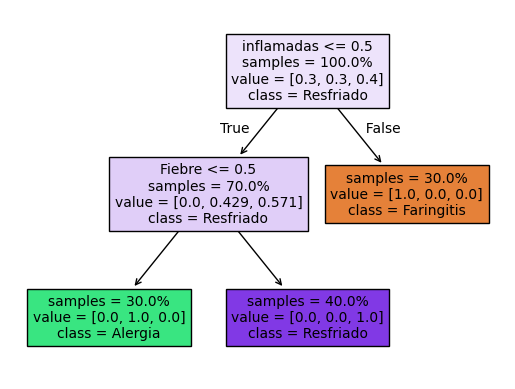

In [13]:
arbol = tree.plot_tree(dtree, feature_names=vi, class_names=diagnostico, filled=True, impurity=False, proportion=True)
plt.show()

## MODELO PARA PREDECIR SI UNA PERSONA ASISTIRA A UN EVENTO O NO

In [14]:
datos = pd.read_csv('Dataset/eventos.csv')
print(datos.shape)
datos.head()

(15, 5)


,Edad,Experiencia,Calificacion,Pais,Asistir
0,36,10,6,Ecuador,Si
1,27,8,7,Colombia,No
2,45,1,8,Argentina,Si
3,18,2,5,Argentina,Si
4,31,4,8,Mexico,Si


In [15]:
# informacion de los dataframes
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Edad          15 non-null     int64
 1   Experiencia   15 non-null     int64
 2   Calificacion  15 non-null     int64
 3   Pais          15 non-null     str  
 4   Asistir       15 non-null     str  
dtypes: int64(3), str(2)
memory usage: 732.0 bytes


In [16]:
# resumen estadistico del dataset
datos.describe()

,Edad,Experiencia,Calificacion
count,15.000000,15.000000,15.000000
mean,28.866667,4.466667,6.800000
std,8.830682,3.270357,1.656157
min,18.000000,0.000000,3.000000
25%,23.000000,2.000000,6.000000
50%,27.000000,4.000000,7.000000
75%,32.000000,7.500000,8.000000
max,48.000000,10.000000,9.000000


Mapear los atributos no numericos

In [17]:
datos['Pais'] = datos['Pais'].map({'Ecuador': 0, 'Colombia': 1, 'Argentina': 2, 'Mexico': 3})
datos['Asistir'] = datos['Asistir'].map({'No': 0, 'Si': 1})
datos.head(3)


,Edad,Experiencia,Calificacion,Pais,Asistir
0,36,10,6,0,1
1,27,8,7,1,0
2,45,1,8,2,1


In [18]:
datos.Pais.value_counts()

Pais
0    5
1    4
2    3
3    3
Name: count, dtype: int64

In [19]:

datos.Asistir.value_counts()

Asistir
0    8
1    7
Name: count, dtype: int64

Dividir en variables independientes y variable dependiente

In [20]:
vi= datos.columns[:-1].tolist()
print(vi)
x = datos[vi].values
y = datos['Asistir']


['Edad', 'Experiencia', 'Calificacion', 'Pais']


Aplicamos el algoritmo de clasificacion, entrenamos (aprende) y predecir

In [21]:
dtree = DecisionTreeClassifier() #algoritmo de clasificacion
dtree.fit(x, y) # Entrenamiento del modelo .fit()  --> Aprende el algoritmo a partir de los datos de entrenamiento (x) y las etiquetas (y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [22]:
datos.columns

Index(['Edad', 'Experiencia', 'Calificacion', 'Pais', 'Asistir'], dtype='str')

In [23]:
dtree.predict([[40, 7, 6, 0]]) # Ecuador y si asiste
#dtree.predict([[18, 3, 10, 3]]) # Mexico y si asiste 
#dtree.predict([[27, 8, 7, 4]]) # Colombiano y no asiste

array([1])

reglas del arbol de clasificacion

In [ ]:
    from sklearn import tree
reglas_arbol = tree.export_text(dtree, feature_names=vi, class_names=["No","Si"], show_weights=True, decimals=0, spacing=5)
print(reglas_arbol)

|----- Edad <= 21
|     |----- weights: [0, 3] class: Si
|----- Edad >  21
|     |----- Edad <= 30
|     |     |----- weights: [6, 0] class: No
|     |----- Edad >  30
|     |     |----- Experiencia <= 8
|     |     |     |----- weights: [0, 3] class: Si
|     |     |----- Experiencia >  8
|     |     |     |----- Experiencia <= 10
|     |     |     |     |----- weights: [2, 0] class: No
|     |     |     |----- Experiencia >  10
|     |     |     |     |----- weights: [0, 1] class: Si



graficamos el arbol

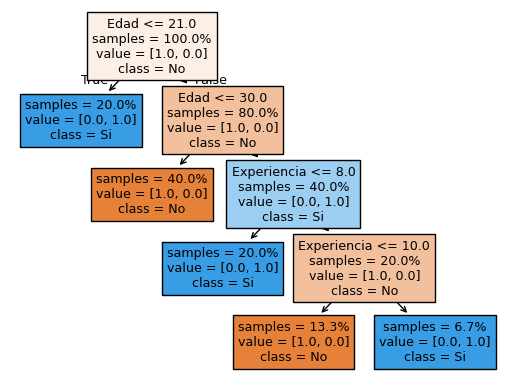

In [25]:
arbol = tree.plot_tree(dtree, feature_names=vi, class_names=["No","Si"], filled=True, impurity=False, proportion=True, precision=0) 
plt.show()

## ME GUSTA EL CINE ?


In [26]:
datos=pd.read_excel('Dataset/Cine.xlsx')
print(datos.shape)
datos.head()

(7, 4)


,Popcorn,Soda,Edad,Cine
0,1,1,7,0
1,1,0,12,0
2,0,1,18,1
3,0,1,35,1
4,1,1,38,1


In [27]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Popcorn  7 non-null      int64
 1   Soda     7 non-null      int64
 2   Edad     7 non-null      int64
 3   Cine     7 non-null      int64
dtypes: int64(4)
memory usage: 356.0 bytes


In [28]:
vi = datos.columns[:-1].tolist()
print(vi)
x = datos[vi].values
y = datos['Cine']

['Popcorn', 'Soda', 'Edad']


In [29]:
dtree = DecisionTreeClassifier() #algoritmo de clasificacion
dtree.fit(x, y) # Entrenamiento del modelo .fit()  --> Aprende el algoritmo a partir de los datos de entrenamiento (x) y las etiquetas (y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [30]:
datos.columns

Index(['Popcorn', 'Soda', 'Edad', 'Cine'], dtype='str')

In [31]:

pre1 = dtree.predict([[1, 1, 18]])[0] 
pre2 =dtree.predict([[0, 0, 25]])[0]
map = {0: 'No me gusta', 1: 'Si me gusta'}
print(pre1)
print(pre2)
print(map[pre1])
print(map[pre2])


1
0
Si me gusta
No me gusta


In [32]:
from sklearn import tree
reglas_arbol = tree.export_text(dtree, feature_names=vi, class_names=["No","Si"], show_weights=True, decimals=0, spacing=5)
print(reglas_arbol)

|----- Soda <= 0
|     |----- weights: [3, 0] class: No
|----- Soda >  0
|     |----- Edad <= 12
|     |     |----- weights: [1, 0] class: No
|     |----- Edad >  12
|     |     |----- weights: [0, 3] class: Si



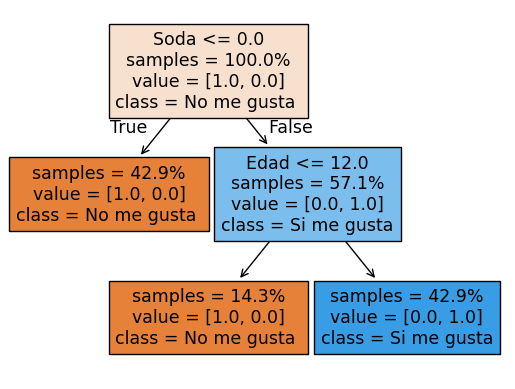

In [33]:
arbol = tree.plot_tree(dtree, feature_names=vi, class_names=["No me gusta ","Si me gusta"], filled=True, impurity=False, proportion=True, precision=0)
plt.show()

## Voy a jugar golf?


Archivo: golf.xlsx

In [34]:
df = pd.read_excel('Dataset/golf.xlsx')
print(df.shape)
df.head(14)

(14, 5)


,Outlook,Temperature,Humidity,Wind,Play
0,sunny,85,85,False,no
1,sunny,80,90,True,no
2,overcast,83,78,False,yes
3,rain,70,96,False,yes
4,rain,68,80,False,yes
5,rain,65,70,True,no
6,overcast,64,65,True,yes
7,sunny,72,95,False,no
8,sunny,69,70,False,yes
9,rain,75,80,False,yes


Mapeo de datos

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Outlook      14 non-null     str  
 1   Temperature  14 non-null     int64
 2   Humidity     14 non-null     int64
 3   Wind         14 non-null     bool 
 4   Play         14 non-null     str  
dtypes: bool(1), int64(2), str(2)
memory usage: 594.0 bytes


In [36]:
# mapeo de wind 
#df['Wind'] = df['Wind'].map({False: 0, True: 1})

In [37]:
# mapeo de play
df['Play'] = df['Play'].map({'no': 0, 'yes': 1})

In [38]:
# mapeo de outlook
df['Outlook'] = df ['Outlook'].map({'sunny': 0, 'overcast': 1, 'rain': 2})

In [39]:
df.head(14)

,Outlook,Temperature,Humidity,Wind,Play
0,0,85,85,False,0
1,0,80,90,True,0
2,1,83,78,False,1
3,2,70,96,False,1
4,2,68,80,False,1
5,2,65,70,True,0
6,1,64,65,True,1
7,0,72,95,False,0
8,0,69,70,False,1
9,2,75,80,False,1


In [40]:
# Separar por variables 
vi = df.columns[:-1].tolist() # variable independiente
print (vi)
x = df[vi].values
y = df['Play']

['Outlook', 'Temperature', 'Humidity', 'Wind']


In [41]:
# entrenar el modelo
dtree = DecisionTreeClassifier(random_state=0) #algoritmo de clasificacion
dtree.fit(x, y) # Entrenamiento del modelo .fit()  --> Aprende el algoritmo a partir de los datos de entrenamiento (x) y las etiquetas (y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [42]:
# funcion para reemplazar los valores numericos por los originales
def reemplazar_valores(prediccion):
    if prediccion == 0:
        return 'no juego'
    else:
        return 'si juego'

In [43]:
df.columns

Index(['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play'], dtype='str')

In [44]:
# prueba del modelo
prediccion =dtree.predict([[2, 80, 56, 0]])[0] 
#prediccion2 = dtree.predict([[0, 80, 90, 0]])[0] 
reemplazar_valores(prediccion)


'si juego'

In [45]:
#reemplazar_valores(prediccion2)

In [46]:
# generar reglas del arbol
from sklearn import tree
arbol = tree.export_text(dtree, feature_names=vi, class_names=["no juego","si juego"], show_weights=True, decimals=0, spacing=5)
print(arbol)

|----- Outlook <= 0
|     |----- Humidity <= 78
|     |     |----- weights: [0, 2] class: si juego
|     |----- Humidity >  78
|     |     |----- weights: [3, 0] class: no juego
|----- Outlook >  0
|     |----- Wind <= 0
|     |     |----- weights: [0, 5] class: si juego
|     |----- Wind >  0
|     |     |----- Outlook <= 2
|     |     |     |----- weights: [0, 2] class: si juego
|     |     |----- Outlook >  2
|     |     |     |----- weights: [2, 0] class: no juego



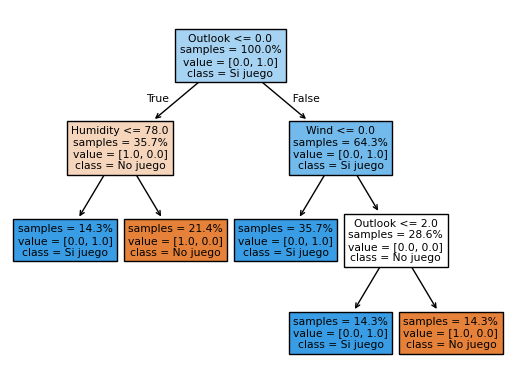

In [47]:
arbol = tree.plot_tree(dtree, feature_names=vi, class_names=["No juego","Si juego"], filled=True, impurity=False, proportion=True, precision=0)
plt.show()

Que tan bueno es el modelo

In [48]:
dtree.score(x, y)

1.0

## Un paciente esta enfermo o no 

Dataset: 'CardiologyMixed.csv'

In [49]:
datos = pd.read_csv('Dataset/CardiologyMixed.csv')
datos.head()

,Edad,Genero,Pecho,presion,colesterol,azucar,eco,pulso,angina,peak,slope,color,anemia,diagnostico
0,60,Male,Asymptomatic,130,206,False,Hyp,132,True,2.4,Flat,2,Rev,Sick
1,49,Male,AbnormalAngina,130,266,False,Normal,171,False,0.6,Up,0,Normal,Healthy
2,64,Male,Angina,110,211,False,Hyp,144,True,1.8,Flat,0,Normal,Healthy
3,63,Male,Asymptomatic,130,254,False,Hyp,147,False,1.4,Flat,1,Rev,Sick
4,53,Male,Asymptomatic,140,203,True,Hyp,155,True,3.1,Down,0,Rev,Sick


In [50]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Edad         303 non-null    int64  
 1   Genero       303 non-null    str    
 2   Pecho        303 non-null    str    
 3   presion      303 non-null    int64  
 4   colesterol   303 non-null    int64  
 5   azucar       303 non-null    bool   
 6   eco          303 non-null    str    
 7   pulso        303 non-null    int64  
 8   angina       303 non-null    bool   
 9   peak         303 non-null    float64
 10  slope        303 non-null    str    
 11  color        303 non-null    int64  
 12  anemia       303 non-null    str    
 13  diagnostico  303 non-null    str    
dtypes: bool(2), float64(1), int64(5), str(6)
memory usage: 29.1 KB


In [51]:
datos.describe()

,Edad,presion,colesterol,pulso,peak,color
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.623762,246.264026,149.646865,1.039604,0.666667
std,9.082101,17.538143,51.830751,22.905161,1.161075,0.933790
min,29.000000,94.000000,126.000000,71.000000,0.000000,0.000000
25%,47.500000,120.000000,211.000000,133.500000,0.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000
75%,61.000000,140.000000,274.500000,166.000000,1.600000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,3.000000


In [52]:
datos.Pecho.unique().tolist()


[' Asymptomatic', 'AbnormalAngina', 'Angina', 'NoTang']

In [53]:
datos ['Genero'] = datos ['Genero'].map({'Male': 0, 'Female': 1})
datos ['Pecho'] = datos ['Pecho'].map({'Angina': 0, 'AbnormalAngina': 1, 'NoTang': 2, 'Asymptomatic': 3})
datos ['eco'] = datos ['eco'].map({'Normal': 0, 'Hyp': 1, 'Abnormal': 2})
datos ['slope'] = datos ['slope'].map({'Up': 0, 'Flat': 1, 'Down': 2})
datos ['anemia'] = datos ['anemia'].map({'Rev': 0, 'Normal': 1, 'Fix': 2})
datos ['diagnostico'] = datos ['diagnostico'].map({'Sick': 0, 'Healthy': 1})

In [54]:
datos.corr()

,Edad,Genero,Pecho,presion,colesterol,azucar,eco,pulso,angina,peak,slope,color,anemia,diagnostico
Edad,1.000000,0.098447,-0.029346,0.279351,0.213678,0.121308,0.171199,-0.398522,0.096801,0.210013,0.168814,0.365064,-0.065157,-0.225439
Genero,0.098447,1.000000,0.147349,0.056769,0.197912,-0.045032,0.012026,0.044020,-0.141664,-0.096093,-0.030711,-0.083703,0.215154,0.280937
Pecho,-0.029346,0.147349,1.000000,-0.150274,0.026956,0.027572,-0.074352,-0.065035,-0.015961,-0.088462,-0.061883,0.013549,-0.014090,0.054694
presion,0.279351,0.056769,-0.150274,1.000000,0.123174,0.177531,0.152165,-0.046698,0.067616,0.193216,0.121475,0.100691,-0.059365,-0.144931
colesterol,0.213678,0.197912,0.026956,0.123174,1.000000,0.013294,0.173411,-0.009940,0.067023,0.053952,0.004038,0.129625,-0.083096,-0.085239
azucar,0.121308,-0.045032,0.027572,0.177531,0.013294,1.000000,0.052621,-0.008567,0.025665,0.005747,0.059894,0.149329,-0.002364,-0.028046
eco,0.171199,0.012026,-0.074352,0.152165,0.173411,0.052621,1.000000,-0.122812,0.098485,0.168256,0.172463,0.145932,0.033979,-0.181633
pulso,-0.398522,0.044020,-0.065035,-0.046698,-0.009940,-0.008567,-0.122812,1.000000,-0.378812,-0.344187,-0.386784,-0.267777,0.113545,0.421741
angina,0.096801,-0.141664,-0.015961,0.067616,0.067023,0.025665,0.098485,-0.378812,1.000000,0.288223,0.257748,0.150961,-0.233257,-0.436757
peak,0.210013,-0.096093,-0.088462,0.193216,0.053952,0.005747,0.168256,-0.344187,0.288223,1.000000,0.577537,0.298386,-0.209692,-0.430696


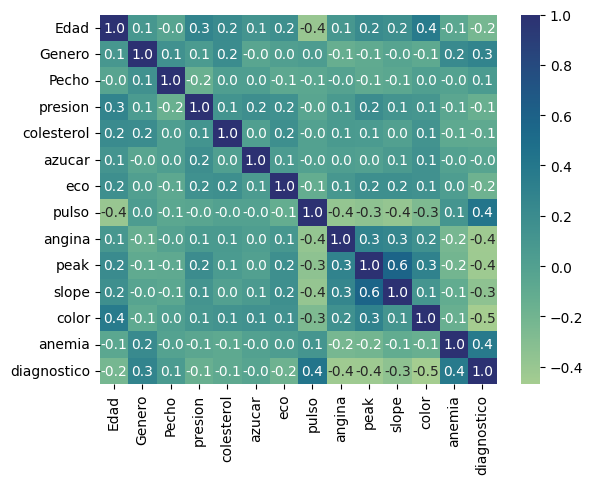

In [55]:
#%pip install seaborn
import seaborn as sns
sns.heatmap(datos.corr(), annot=True, fmt=".1f", cmap='crest');

In [56]:
# Separar por variables
resultado = ['Enfermo', 'Sano']
vi = datos.columns[:-1].tolist() # variable independiente
#print (vi)
caracteristicas = x.columns
x = pd.DataFrame(datos[['color','anemia']])
y = datos['diagnostico']

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
dtree = DecisionTreeClassifier(random_state=0) #algoritmo de clasificacion
dtree.fit(x, y) 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [ ]:
reglas_arbol = tree.export_text(dtree, feature_names=caracteristicas, class_names=resultado, show_weights=True, decimals=0, spacing=5)
print(reglas_arbol)


|----- anemia <= 0
|     |----- color <= 0
|     |     |----- weights: [31, 22] class: Enfermo
|     |----- color >  0
|     |     |----- color <= 2
|     |     |     |----- color <= 2
|     |     |     |     |----- weights: [29, 4] class: Enfermo
|     |     |     |----- color >  2
|     |     |     |     |----- weights: [20, 0] class: Enfermo
|     |     |----- color >  2
|     |     |     |----- weights: [10, 2] class: Enfermo
|----- anemia >  0
|     |----- color <= 0
|     |     |----- anemia <= 2
|     |     |     |----- weights: [12, 106] class: Sano
|     |     |----- anemia >  2
|     |     |     |----- weights: [2, 6] class: Sano
|     |----- color >  0
|     |     |----- anemia <= 2
|     |     |     |----- color <= 2
|     |     |     |     |----- color <= 2
|     |     |     |     |     |----- weights: [12, 17] class: Sano
|     |     |     |     |----- color >  2
|     |     |     |     |     |----- weights: [7, 7] class: Enfermo
|     |     |     |----- color >  2
|     

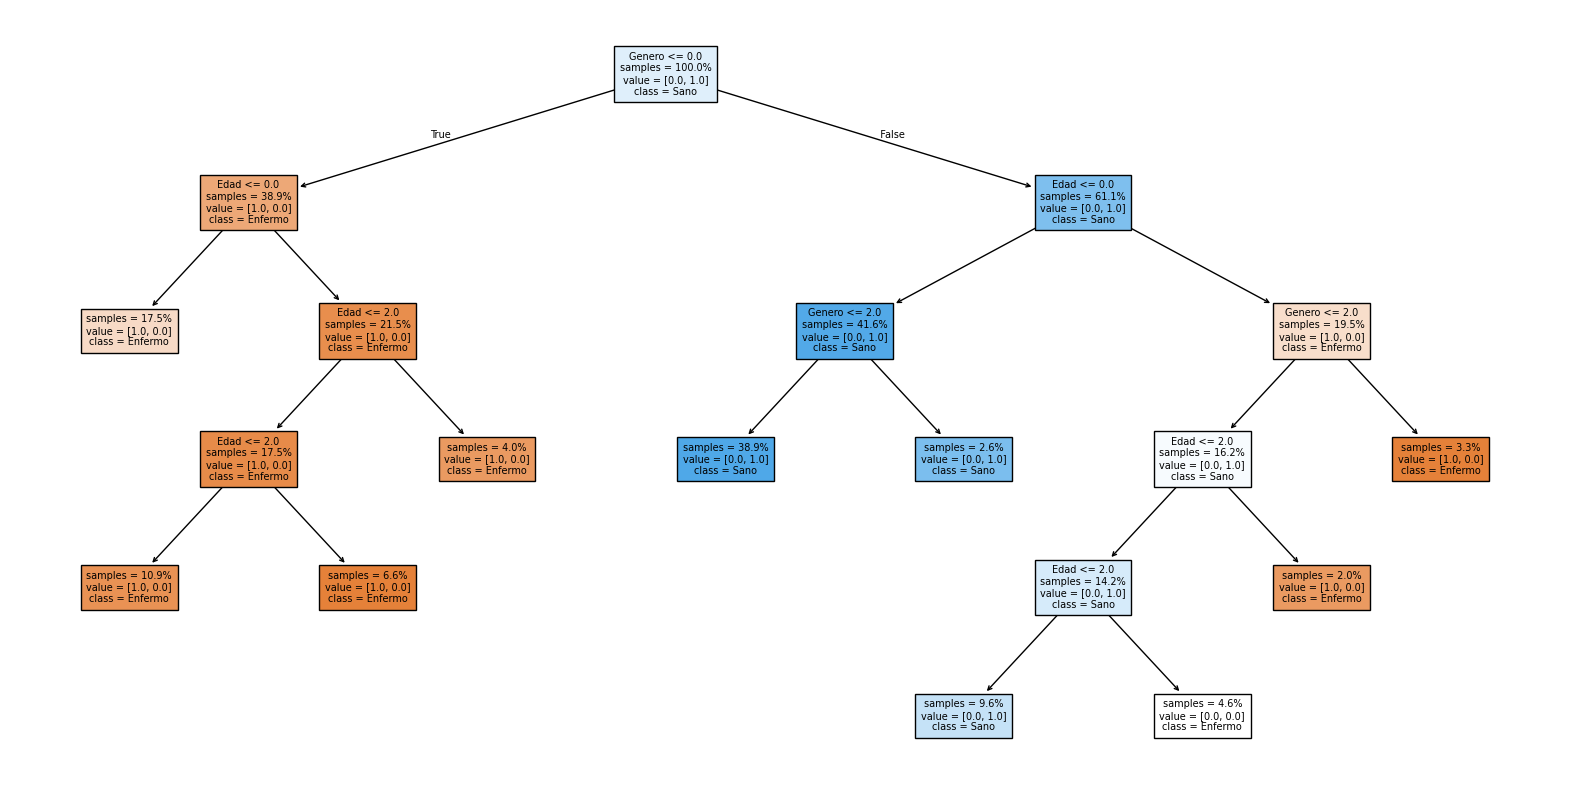

In [ ]:
plt.figure(figsize=(20,10))
arbol = tree.plot_tree(dtree, feature_names=vi, class_names=resultado, filled=True, impurity=False, proportion=True, fontsize=7, precision=0, max_depth=7,)

## Clinical records 

In [69]:
df = pd.read_excel('Dataset/heart_failure_clinical_records_dataset.xlsx')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75,0,582,0,20,1,265000,19,130,1,0,4,1
1,55,0,7861,0,38,0,26335803,11,136,1,0,6,1
2,65,0,146,0,20,0,162000,13,129,1,1,7,1
3,50,1,111,0,20,0,210000,19,137,1,0,7,1
4,65,1,160,1,20,0,327000,27,116,0,0,8,1


In [70]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       299 non-null    int64
 1   anaemia                   299 non-null    int64
 2   creatinine_phosphokinase  299 non-null    int64
 3   diabetes                  299 non-null    int64
 4   ejection_fraction         299 non-null    int64
 5   high_blood_pressure       299 non-null    int64
 6   platelets                 299 non-null    int64
 7   serum_creatinine          299 non-null    int64
 8   serum_sodium              299 non-null    int64
 9   sex                       299 non-null    int64
 10  smoking                   299 non-null    int64
 11  time                      299 non-null    int64
 12  DEATH_EVENT               299 non-null    int64
dtypes: int64(13)
memory usage: 30.5 KB


In [71]:
df.DEATH_EVENT.value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Graficar algunos datos

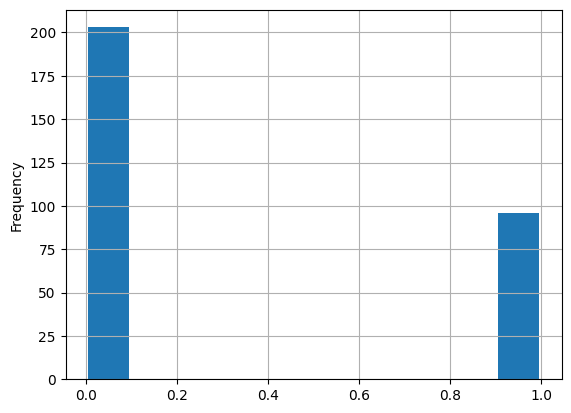

In [63]:
df.DEATH_EVENT.plot(kind='hist', grid=True, rwidth=0.9);

In [74]:
df.age.unique()

array([   75,    55,    65,    50,    90,    60,    80,    62,    45,
          49,    82,    87,    70,    48,    68,    53,    95,    58,
          94,    85,    69,    72,    51,    57,    42,    41,    67,
          79,    59,    44,    63,    86,    66,    43,    46,    61,
          81,    52,    64,    40, 60667,    73,    77,    78,    54,
          47,    56])

sustituimos los valores de edad con 60667 por 61 (>0.5)

In [75]:
df['age'] = df['age'].replace({60667:61})

In [76]:
df.age.unique()

array([75, 55, 65, 50, 90, 60, 80, 62, 45, 49, 82, 87, 70, 48, 68, 53, 95,
       58, 94, 85, 69, 72, 51, 57, 42, 41, 67, 79, 59, 44, 63, 86, 66, 43,
       46, 61, 81, 52, 64, 40, 73, 77, 78, 54, 47, 56])

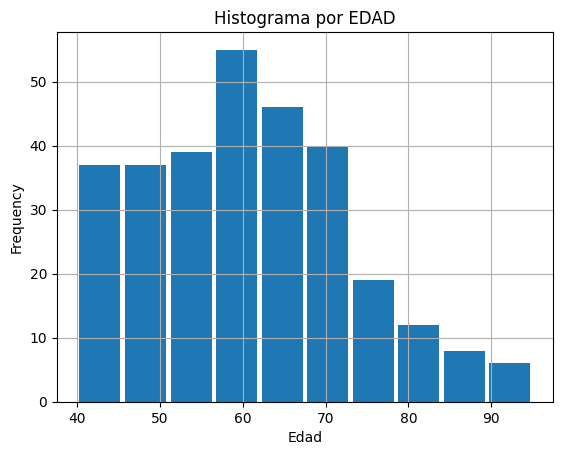

In [79]:
df.age.plot(kind='hist',title='Histograma por EDAD',xlabel='Edad', grid=True, rwidth=0.9);

In [ ]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,2.990000e+02,299.000000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,466.227425,0.431438,581.839465,0.418060,38.083612,0.351171,2.443328e+06,20.190635,136.625418,0.648829,0.32107,130.260870,0.32107
std,4948.431408,0.496107,970.287881,0.494067,11.834841,0.478136,7.229746e+06,35.299397,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,2.510000e+04,1.000000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,2.125000e+05,7.000000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,2.620000e+05,11.000000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,3.320000e+05,15.000000,140.000000,1.000000,1.00000,203.000000,1.00000
max,60667.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,2.633580e+07,183.000000,148.000000,1.000000,1.00000,285.000000,1.00000


In [ ]:
df.corr()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
age,1.000000,0.094415,-0.038686,0.096575,-0.021273,0.025810,-0.024353,-0.027989,-0.011761,-0.025429,-0.056387,0.043136,0.032059
anaemia,0.094415,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.190516,-0.139421,0.041882,-0.094769,-0.107290,-0.141414,0.066270
creatinine_phosphokinase,-0.038686,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.174792,0.038866,0.059550,0.079791,0.002421,-0.009346,0.062728
diabetes,0.096575,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,-0.034306,-0.050187,-0.089551,-0.157730,-0.147173,0.033726,-0.001943
ejection_fraction,-0.021273,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.085755,-0.066660,0.175902,-0.148386,-0.067315,0.041729,-0.268603
high_blood_pressure,0.025810,0.038182,-0.070590,-0.012732,0.024445,1.000000,-0.019047,-0.033008,0.037109,-0.104615,-0.055711,-0.196439,0.079351
platelets,-0.024353,-0.190516,0.174792,-0.034306,0.085755,-0.019047,1.000000,0.628101,-0.072210,-0.007279,0.025566,-0.021768,0.050396
serum_creatinine,-0.027989,-0.139421,0.038866,-0.050187,-0.066660,-0.033008,0.628101,1.000000,-0.097610,0.035394,0.015591,-0.109768,0.166215
serum_sodium,-0.011761,0.041882,0.059550,-0.089551,0.175902,0.037109,-0.072210,-0.097610,1.000000,-0.027566,0.004813,0.087640,-0.195204
sex,-0.025429,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.007279,0.035394,-0.027566,1.000000,0.445892,-0.015608,-0.004316


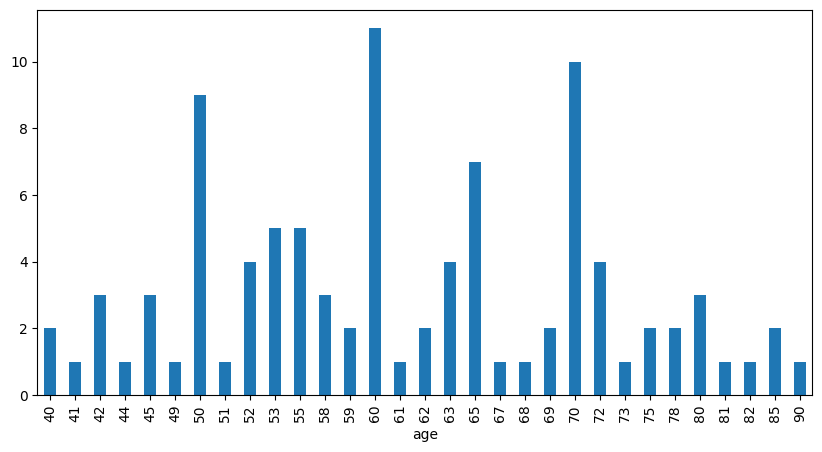

In [92]:
# graficar los pacientes  edad fuman x edad
plt.figure(figsize=(10,5))
df1 = df[df['smoking'] == 1]
cuenta_edad_fumadores = df1.groupby('age')['smoking'].count()
cuenta_edad_fumadores.plot(kind='bar');

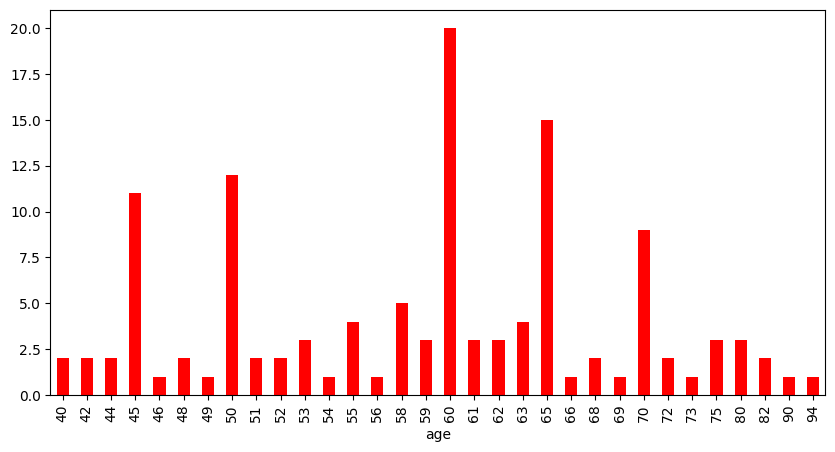

In [95]:
# graficar los pacientes  con diabetes x edad
plt.figure(figsize=(10,5))
df1 = df[df['diabetes'] == 1]
cuenta_edad_diabeticos = df1.groupby('age')['diabetes'].count()
cuenta_edad_diabeticos.plot(kind='bar', color='red');

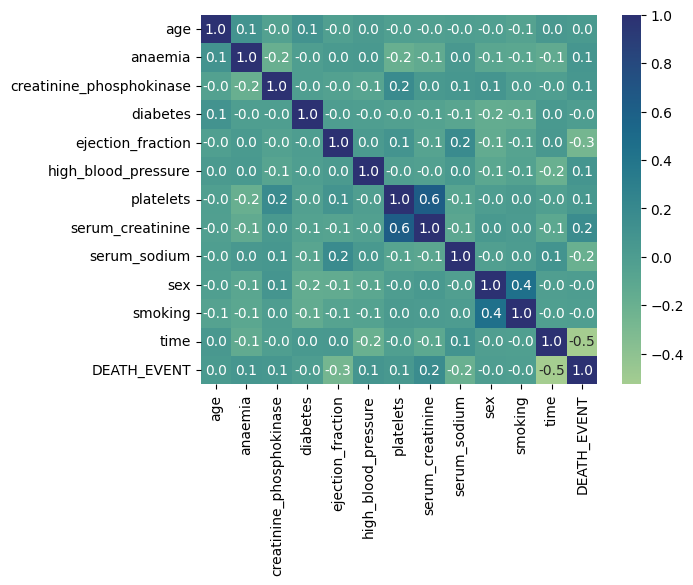

In [ ]:
sns.heatmap(df.corr(), annot=True, fmt=".1f", cmap='crest');

In [149]:
# Separar por variables
resultado = ['No Fallece', 'Fallece']

X = df.drop('DEATH_EVENT', axis=1)
#caracteristicas = x.columns
#x = pd.DataFrame(datos[['color','anemia']])
y = pd.DataFrame(df['DEATH_EVENT'])



In [150]:
dtree = DecisionTreeClassifier(random_state=0) #algoritmo de clasificacion
dtree.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [103]:
caracteristicas = df.columns[:-1]
caracteristicas

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time'],
      dtype='str')

In [102]:
reglas_arbol = tree.export_text(dtree, feature_names=vi, class_names=resultado, show_weights=True, decimals=0, spacing=5)
print(reglas_arbol)

|----- time <= 74
|     |----- serum_sodium <= 136
|     |     |----- ejection_fraction <= 48
|     |     |     |----- weights: [0, 32] class: Fallece
|     |     |----- ejection_fraction >  48
|     |     |     |----- anaemia <= 0
|     |     |     |     |----- weights: [2, 0] class: No Fallece
|     |     |     |----- anaemia >  0
|     |     |     |     |----- weights: [0, 5] class: Fallece
|     |----- serum_sodium >  136
|     |     |----- time <= 48
|     |     |     |----- creatinine_phosphokinase <= 86
|     |     |     |     |----- weights: [2, 0] class: No Fallece
|     |     |     |----- creatinine_phosphokinase >  86
|     |     |     |     |----- creatinine_phosphokinase <= 1818
|     |     |     |     |     |----- age <= 52
|     |     |     |     |     |     |----- diabetes <= 0
|     |     |     |     |     |     |     |----- weights: [0, 3] class: Fallece
|     |     |     |     |     |     |----- diabetes >  0
|     |     |     |     |     |     |     |----- weights: 

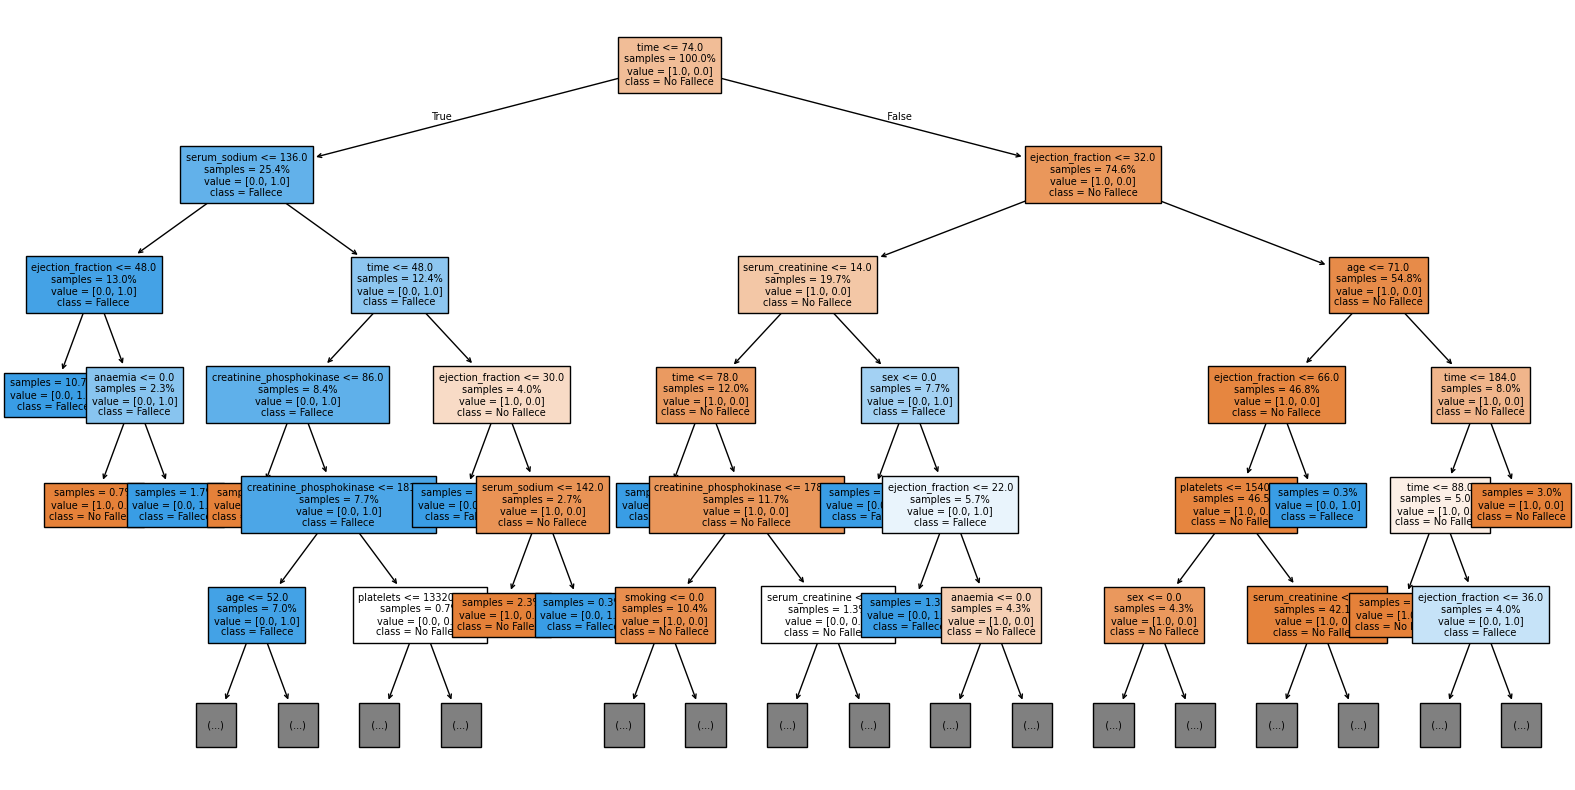

In [105]:
# graficar arbol de decision
plt.figure(figsize=(20,10))
arbol = tree.plot_tree(dtree, feature_names=caracteristicas, class_names=resultado, filled=True, impurity=False, proportion=True, fontsize=7, precision=0, max_depth=5,)
plt.show()

Dividir los datos en datos de ENTRENAMIENTO(training) y datos de PRUEBA(test)

In [151]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2, # tamaño del conjunto de prueba (25% para prueba, 75% para entrenamiento)
                                                     random_state=0) 

In [153]:
clasificador = DecisionTreeClassifier(criterion='entropy', random_state=0)
clasificador.fit(x_train, y_train)
y_pred = clasificador.predict(x_test)
score = clasificador.score(x_test, y_test)
print("Precisión del modelo: %2.2f" % score)

Precisión del modelo: 0.83


Seleccionar algunad variables

In [119]:
df.corr()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
age,1.000000,0.087898,-0.081532,-0.101123,0.060242,0.093554,0.029993,0.165686,-0.045952,0.065163,0.018732,-0.224115,0.253389
anaemia,0.087898,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.190516,-0.139421,0.041882,-0.094769,-0.107290,-0.141414,0.066270
creatinine_phosphokinase,-0.081532,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.174792,0.038866,0.059550,0.079791,0.002421,-0.009346,0.062728
diabetes,-0.101123,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,-0.034306,-0.050187,-0.089551,-0.157730,-0.147173,0.033726,-0.001943
ejection_fraction,0.060242,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.085755,-0.066660,0.175902,-0.148386,-0.067315,0.041729,-0.268603
high_blood_pressure,0.093554,0.038182,-0.070590,-0.012732,0.024445,1.000000,-0.019047,-0.033008,0.037109,-0.104615,-0.055711,-0.196439,0.079351
platelets,0.029993,-0.190516,0.174792,-0.034306,0.085755,-0.019047,1.000000,0.628101,-0.072210,-0.007279,0.025566,-0.021768,0.050396
serum_creatinine,0.165686,-0.139421,0.038866,-0.050187,-0.066660,-0.033008,0.628101,1.000000,-0.097610,0.035394,0.015591,-0.109768,0.166215
serum_sodium,-0.045952,0.041882,0.059550,-0.089551,0.175902,0.037109,-0.072210,-0.097610,1.000000,-0.027566,0.004813,0.087640,-0.195204
sex,0.065163,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.007279,0.035394,-0.027566,1.000000,0.445892,-0.015608,-0.004316


In [156]:
df.columns
#x = df[['age','ejection_fraction','serum_creatinine', 'serum_sodium',  'smoking', 'time']]
X = df.drop([ 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'high_blood_pressure', 'platelets',
       'sex', 'smoking', 'DEATH_EVENT'] , axis=1)
y = pd.DataFrame(df['DEATH_EVENT'])

In [159]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25, # tamaño del conjunto de prueba (25% para prueba, 75% para entrenamiento)
                                                     random_state=0) 
clasificador = DecisionTreeClassifier(criterion='gini', random_state=0)
clasificador.fit(x_train, y_train)
y_pred = clasificador.predict(x_test)
score = clasificador.score(x_test, y_test)
print("Precisión del modelo: %2.2f" % score)

Precisión del modelo: 0.83
